## В данном ноутбуке разработка бейзлайнов. Оценка на метриках
Строим popularity-baseline, user-mean baseline, item-mean baseline. В данном контексте подразумевается выдача неперсоанализорованных рекоммендаций для пользователя. 

* Popularity-baseline 

    Мы предполагаем, что все пользователи одинаковы и предпочитают наиболее популярные фильмы

* User-mean-beseline

* Item-mean-baseline

Сравнивать будем по метрикам Precision@k, Recall@k, NDCG 

In [15]:
import pandas as pd
import numpy as np
from pathlib import Path
from typing import List, Dict
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
ARTIFACTS_DIR = '../artifacts'
FIGURES_DIR = Path(ARTIFACTS_DIR) / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [16]:
df = pd.read_parquet('../src/data/preprocessed_data/full_data.parquet', columns=['movieId', 'title', 'avg_film_rating', 'film_rating_count', 'userId', 'rating', 'timestamp'])
df.head()

,movieId,title,avg_film_rating,film_rating_count,userId,rating,timestamp
0,1,Toy Story (1995),3.92093,215.0,1,4.0,2000-07-30 18:45:03
1,1,Toy Story (1995),3.92093,215.0,5,4.0,2000-07-30 18:20:47
2,1,Toy Story (1995),3.92093,215.0,7,4.5,2000-07-30 18:37:04
3,1,Toy Story (1995),3.92093,215.0,15,2.5,2000-07-30 19:03:35
4,1,Toy Story (1995),3.92093,215.0,17,4.5,2000-07-30 18:48:51


In [17]:
#выводим топ-5 фильмов по количеству оценок
popularity_by_rating_count = df.drop_duplicates(subset='movieId').sort_values(by='film_rating_count',ascending=False)
popularity_by_rating_count.head(10)

,movieId,title,avg_film_rating,film_rating_count,userId,rating,timestamp
10019,356,Forrest Gump (1994),4.164134,329.0,1,4.0,2004-08-29 02:50:09
8652,318,"Shawshank Redemption, The (1994)",4.429022,317.0,2,3.0,2000-03-21 03:44:27
7860,296,Pulp Fiction (1994),4.197068,307.0,1,3.0,2016-07-09 08:15:42
16228,593,"Silence of the Lambs, The (1991)",4.161290,279.0,1,4.0,2015-11-03 17:36:21
45014,2571,"Matrix, The (1999)",4.192446,278.0,1,5.0,2015-11-15 14:40:35
6853,260,Star Wars: Episode IV - A New Hope (1977),4.231076,251.0,1,5.0,2003-06-30 21:02:02
13085,480,Jurassic Park (1993),3.750000,238.0,1,4.0,1997-04-07 07:37:59
3387,110,Braveheart (1995),4.031646,237.0,1,4.0,2014-06-22 17:57:42
15651,589,Terminator 2: Judgment Day (1991),3.970982,224.0,5,3.0,2015-05-18 16:53:59
14106,527,Schindler's List (1993),4.225000,220.0,1,5.0,1997-02-19 12:07:17


In [18]:
user_means = df.groupby('userId')['rating'].mean()
user_means


userId
1      4.366379
2      3.948276
3      2.435897
4      3.555556
5      3.636364
         ...   
606    3.657399
607    3.786096
608    3.134176
609    3.270270
610    3.688556
Name: rating, Length: 610, dtype: float64

In [19]:
item_means = df.groupby('movieId')['rating'].mean()
item_means

movieId
1         3.920930
2         3.431818
3         3.259615
4         2.357143
5         3.071429
            ...   
193581    4.000000
193583    3.500000
193585    3.500000
193587    3.500000
193609    4.000000
Name: rating, Length: 9724, dtype: float64

In [20]:
#функции для подсчета метрик

def precision_at_k(relevant, recommended, k=10):
    recommended_k = recommended[:k]
    hits = len(set(relevant) & set(recommended_k))
    return hits / k if k > 0 else 0

def recall_at_k(relevant, recommended, k=10):
    recommended_k = set(recommended[:k])
    hits = len(set(relevant) & recommended_k)
    return hits / len(relevant) if relevant else 0

def ndcg_at_k(relevant_with_ratings, recommended, k=10):
    recommended_k = recommended[:k]

    dcg = 0
    for i, item in enumerate(recommended_k):
        if item in relevant_with_ratings:
            gain = 2 ** relevant_with_ratings[item] - 1
            dcg += gain / np.log2(i + 2)
    
    sorted_ratings = sorted(relevant_with_ratings.values(), reverse=True)[:k]
    idcg = 0
    for i, rating in enumerate(sorted_ratings):
        gain = 2 ** rating - 1
        idcg += gain / np.log2(i + 2)
    
    return dcg / idcg if idcg > 0 else 0

def evaluate_model(recommend_func, data_df, all_items, k=10, verbose=False):
    precisions = []
    recalls = []
    ndcgs = []
    users_processed = 0
    
    for user_id in data_df['userId'].unique():
        user_data = data_df[data_df['userId'] == user_id]
        relevant = user_data[user_data['rating'] >= 4]
        
        if len(relevant) == 0:
            continue
        
        relevant_ids = relevant['movieId'].tolist()
        relevant_dict = dict(zip(relevant['movieId'], relevant['rating']))
        
        recommendations = recommend_func(user_id, all_items, k)
        
        precisions.append(precision_at_k(relevant_ids, recommendations, k))
        recalls.append(recall_at_k(relevant_ids, recommendations, k))
        ndcgs.append(ndcg_at_k(relevant_dict, recommendations, k))
        
        users_processed += 1
        if verbose and users_processed % 100 == 0:
            print(f"  Обработано {users_processed} пользователей...")
    
    return {
        'precision@10': np.mean(precisions),
        'recall@10': np.mean(recalls),
        'ndcg@10': np.mean(ndcgs),
        'users_evaluated': len(precisions)
    }


Для построения прогнозов мы учитываем разделение данных по времени, потому что предпочтения пользователей могут меняться с течением времени

In [21]:
df_sorted = df.sort_values('timestamp').reset_index(drop=True)
n = len(df_sorted)
train_end = int(n * 0.7)
val_end = int(n * 0.85)  # 70 + 15 = 85

train_df = df_sorted[:train_end]
val_df = df_sorted[train_end:val_end]
test_df = df_sorted[val_end:]

train_users = set(train_df['userId'].unique())
val_users = set(val_df['userId'].unique())
test_users = set(test_df['userId'].unique())

print("пересечения пользоавтелей по выборкам")

print(f"Train ∩ Validation: {len(train_users & val_users)} пользователей")
print(f"Train ∩ Test:       {len(train_users & test_users)} пользователей") #смотрим пересечения пользователей по выборкам
print(f"Validation ∩ Test:  {len(val_users & test_users)} пользователей")

print("размер выборок")

print(f"  train_df: {train_df.shape}")
print(f"  val_df:   {val_df.shape} ")
print(f"  test_df:  {test_df.shape}")

пересечения пользоавтелей по выборкам
Train ∩ Validation: 605 пользователей
Train ∩ Test:       602 пользователей
Validation ∩ Test:  597 пользователей
размер выборок
  train_df: (70585, 7)
  val_df:   (15125, 7) 
  test_df:  (15126, 7)


In [22]:
popularity_stats = train_df.groupby('movieId').agg(
    rating_count=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

popularity_items = popularity_stats.sort_values('rating_count', ascending=False)['movieId'].tolist()

print("топ-10 популярных фильмов (обучено на train):")
popularity_top10 = train_df[train_df['movieId'].isin(popularity_items[:10])].drop_duplicates('movieId')[['movieId', 'title']]
for i, row in popularity_top10.iterrows():
    count = popularity_stats[popularity_stats['movieId'] == row['movieId']]['rating_count'].values[0]
    print(f"  {i+1}. {row['title']} ({count} оценок)")

def recommend_popularity(user_id, all_items, k=10):
    return popularity_items[:k]

print("\nОценка на validation:")
pop_metrics = evaluate_model(recommend_popularity, val_df, df['movieId'].unique(), k=10)
print(f"  Precision@10: {pop_metrics['precision@10']:.4f}")
print(f"  Recall@10:    {pop_metrics['recall@10']:.4f}")
print(f"  NDCG@10:      {pop_metrics['ndcg@10']:.4f}")
print(f"  Оценено пользователей: {pop_metrics['users_evaluated']}")

топ-10 популярных фильмов (обучено на train):
  206. Pulp Fiction (1994) (256 оценок)
  732. Godfather, The (1972) (192 оценок)
  2070. Apollo 13 (1995) (201 оценок)
  3022. Star Wars: Episode VI - Return of the Jedi (1983) (196 оценок)
  3620. Star Wars: Episode V - The Empire Strikes Back (1980) (211 оценок)
  6422. Schindler's List (1993) (220 оценок)
  6614. Jurassic Park (1993) (238 оценок)
  15088. Toy Story (1995) (215 оценок)
  16004. Usual Suspects, The (1995) (204 оценок)
  34046. Forrest Gump (1994) (305 оценок)

Оценка на validation:
  Precision@10: 0.0059
  Recall@10:    0.0059
  NDCG@10:      0.0092
  Оценено пользователей: 591


In [23]:
user_means = train_df.groupby('userId')['rating'].mean().to_dict()
global_mean = train_df['rating'].mean()

print(f"global avg (train): {global_mean:.3f}")

def predict_user_mean(user_id, item_id):
    return user_means.get(user_id, global_mean)

def recommend_user_mean(user_id, all_items, k=10):
    predictions = [(item_id, predict_user_mean(user_id, item_id)) for item_id in all_items]
    predictions.sort(key=lambda x: x[1], reverse=True)
    return [item_id for item_id, _ in predictions[:k]]

print("\nОценка на validation:")
user_metrics = evaluate_model(recommend_user_mean, val_df, df['movieId'].unique(), k=10)
print(f"  Precision@10: {user_metrics['precision@10']:.4f}")
print(f"  Recall@10:    {user_metrics['recall@10']:.4f}")
print(f"  NDCG@10:      {user_metrics['ndcg@10']:.4f}")
print(f"  Оценено пользователей: {user_metrics['users_evaluated']}")

global avg (train): 3.502

Оценка на validation:
  Precision@10: 0.0019
  Recall@10:    0.0009
  NDCG@10:      0.0015
  Оценено пользователей: 591


In [24]:
item_stats = train_df.groupby('movieId').agg(
    avg_rating=('rating', 'mean'),
    count=('rating', 'count')
).reset_index()

print(f"Всего фильмов в train: {len(item_stats)}")
print("\nПодбор параметра min_ratings на validation:")
all_items = df['movieId'].unique().tolist()
min_ratings_options = [10, 20, 30, 50, 100, 200]
val_results = {}

for min_ratings in min_ratings_options:
    filtered = item_stats[item_stats['count'] >= min_ratings].sort_values('avg_rating', ascending=False)
    items_list = filtered['movieId'].tolist()
    
    def make_recommender(items):
        return lambda user_id, all_items, k=10: items[:k]
    
    recommender = make_recommender(items_list)
    metrics = evaluate_model(recommender, val_df, all_items, k=10)
    val_results[min_ratings] = metrics['ndcg@10']
    
    print(f"  min_ratings={min_ratings:3d}: NDCG@10 = {metrics['ndcg@10']:.4f} (оценено {metrics['users_evaluated']} пользователей)")

#лучший параметр
best_min_ratings = max(val_results.keys(), key=lambda x: val_results[x])
print(f"\nлучший min_ratings = {best_min_ratings} (NDCG@10 = {val_results[best_min_ratings]:.4f})")

item_stats_final = item_stats[item_stats['count'] >= best_min_ratings].sort_values('avg_rating', ascending=False)
item_mean_items_final = item_stats_final['movieId'].tolist()

print(f"\nтоп-10 фильмов по средней оценке (min_ratings={best_min_ratings}):")
for i, item_id in enumerate(item_mean_items_final[:10], 1):
    item_data = item_stats_final[item_stats_final['movieId'] == item_id].iloc[0]
    title = train_df[train_df['movieId'] == item_id]['title'].iloc[0]
    print(f"  {i}. {title} (ср.{item_data['avg_rating']:.3f}, {item_data['count']:.0f} оценок)")
 
def recommend_item_mean(user_id, all_items, k=10):
    return item_mean_items_final[:k]

print("\nОценка на validation:")
item_metrics = evaluate_model(recommend_item_mean, val_df, all_items, k=10)
print(f"  Precision@10: {item_metrics['precision@10']:.4f}")
print(f"  Recall@10:    {item_metrics['recall@10']:.4f}")
print(f"  NDCG@10:      {item_metrics['ndcg@10']:.4f}")
print(f"  Оценено пользователей: {item_metrics['users_evaluated']}")

Всего фильмов в train: 6815

Подбор параметра min_ratings на validation:
  min_ratings= 10: NDCG@10 = 0.0071 (оценено 591 пользователей)
  min_ratings= 20: NDCG@10 = 0.0216 (оценено 591 пользователей)
  min_ratings= 30: NDCG@10 = 0.0293 (оценено 591 пользователей)
  min_ratings= 50: NDCG@10 = 0.0166 (оценено 591 пользователей)
  min_ratings=100: NDCG@10 = 0.0211 (оценено 591 пользователей)
  min_ratings=200: NDCG@10 = 0.0092 (оценено 591 пользователей)

лучший min_ratings = 30 (NDCG@10 = 0.0293)

топ-10 фильмов по средней оценке (min_ratings=30):
  1. Shawshank Redemption, The (1994) (ср.4.402, 117 оценок)
  2. Fight Club (1999) (ср.4.348, 155 оценок)
  3. Star Wars: Episode IV - A New Hope (1977) (ср.4.296, 98 оценок)
  4. Princess Bride, The (1987) (ср.4.293, 46 оценок)
  5. Godfather, The (1972) (ср.4.289, 192 оценок)
  6. Cool Hand Luke (1967) (ср.4.277, 56 оценок)
  7. Rear Window (1954) (ср.4.262, 84 оценок)
  8. Godfather: Part II, The (1974) (ср.4.260, 129 оценок)
  9. Goodfell

In [25]:
comparison = pd.DataFrame({
    'Popularity': pop_metrics,
    'User Mean': user_metrics,
    'Item Mean': item_metrics
}).round(4)

comparison = comparison.drop('users_evaluated')
print(comparison)

              Popularity  User Mean  Item Mean
precision@10      0.0059     0.0019     0.0208
recall@10         0.0059     0.0009     0.0203
ndcg@10           0.0092     0.0015     0.0293


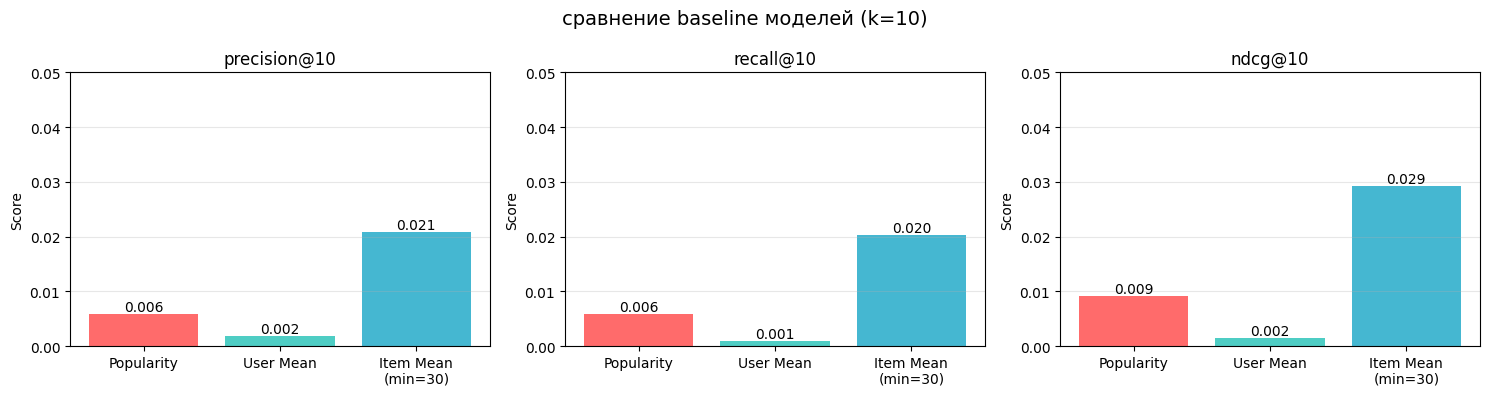

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = ['precision@10', 'recall@10', 'ndcg@10']
models = ['Popularity', 'User Mean', f'Item Mean\n(min={best_min_ratings})']
values = [pop_metrics, user_metrics, item_metrics]

for i, metric in enumerate(metrics):
    ax = axes[i]
    bars = ax.bar(models, 
                  [pop_metrics[metric], user_metrics[metric], item_metrics[metric]],
                  color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 0.05)
    ax.set_ylabel('Score', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('сравнение baseline моделей (k=10)', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'baseline_comparison.png', dpi=300)
plt.show()


In [27]:
sample_user = test_df['userId'].iloc[6752]
#берем случайного пользователяи его любимые фильма
user_likes = test_df[(test_df['userId'] == sample_user) & (test_df['rating'] >= 4)]
print(f"\nПользователь {sample_user}:")
print(f"Реальные любимые фильмы (rating >= 4):")
if len(user_likes) > 0:
    for _, row in user_likes.iterrows():
        print(f"  • {row['title']} (оценка: {row['rating']})")
else:
    print("  Нет фильмов с оценкой >= 4 в тесте")


Пользователь 534:
Реальные любимые фильмы (rating >= 4):
  • Anacleto: Agente secreto (2015) (оценка: 4.0)
  • Fox and the Hound, The (1981) (оценка: 4.5)
  • Final Fantasy: The Spirits Within (2001) (оценка: 4.0)
  • District 13 (Banlieue 13) (2004) (оценка: 4.5)
  • King Kong (2005) (оценка: 4.0)
  • Meet the Robinsons (2007) (оценка: 4.0)
  • Doomsday (2008) (оценка: 4.0)
  • Hellboy II: The Golden Army (2008) (оценка: 4.0)
  • Girl Who Leapt Through Time, The (Toki o kakeru shôjo) (2006) (оценка: 4.5)
  • Jumper (2008) (оценка: 4.0)
  • Chicken Run (2000) (оценка: 4.0)
  • Pitch Black (2000) (оценка: 4.5)
  • The Girl with All the Gifts (2016) (оценка: 5.0)
  • X-Men (2000) (оценка: 4.0)
  • You Only Live Twice (1967) (оценка: 4.0)
  • The Man from Nowhere (2010) (оценка: 4.5)
  • Rise of the Planet of the Apes (2011) (оценка: 4.0)
  • Asterix in America (a.k.a Asterix Conquers America) (Astérix et les Indiens) (1994) (оценка: 4.0)
  • Avengers, The (2012) (оценка: 4.0)
  • Hangov

In [28]:
print(f"\nпример: топ-5 рекомендаций от каждой модели")

print(f"\npopularity:")
for i, item_id in enumerate(popularity_items[:5], 1):
    title = df[df['movieId'] == item_id]['title'].iloc[0]
    print(f"  {i}. {title}")
    
print(f"\nuser mean: {user_means.get(sample_user, global_mean):.2f}):")
for i, item_id in enumerate(popularity_items[:5], 1):
    title = df[df['movieId'] == item_id]['title'].iloc[0]
    print(f"  {i}. {title}")

print(f"\n item mean:")
for i, item_id in enumerate(item_mean_items_final[:5], 1):
    title = df[df['movieId'] == item_id]['title'].iloc[0]
    avg = item_stats_final[item_stats_final['movieId'] == item_id]['avg_rating'].values[0]
    print(f"  {i}. {title} (ср.{avg:.2f})")


пример: топ-5 рекомендаций от каждой модели

popularity:
  1. Forrest Gump (1994)
  2. Pulp Fiction (1994)
  3. Jurassic Park (1993)
  4. Schindler's List (1993)
  5. Toy Story (1995)

user mean: 3.82):
  1. Forrest Gump (1994)
  2. Pulp Fiction (1994)
  3. Jurassic Park (1993)
  4. Schindler's List (1993)
  5. Toy Story (1995)

 item mean:
  1. Shawshank Redemption, The (1994) (ср.4.40)
  2. Fight Club (1999) (ср.4.35)
  3. Star Wars: Episode IV - A New Hope (1977) (ср.4.30)
  4. Princess Bride, The (1987) (ср.4.29)
  5. Godfather, The (1972) (ср.4.29)
